# Movie Recommendation System — Extended Analysis & Models

This notebook builds on the original project. It keeps the parts that worked well
(the IMDB-style weighted rating, the popularity ranking) and adds:

1. **Deeper EDA** — missing data, distributions, genres/keywords, directors/cast, financials.
2. **Metadata that was never used** — `genres`, `keywords`, `cast`, `crew` were sitting in the
   raw CSVs untouched; the original content-based model only looked at `overview` text.
3. **Four different content-based approaches**, compared side by side, both qualitatively
   (actual recommendations for the same movie) and quantitatively (genre/director overlap
   across a sample of 60 movies).
4. **A coverage fix** — the original model could only recommend (and only let you *pick*)
   movies from the top 10% by vote count (~480 of 4,803 movies). That filter is appropriate
   for the *ranking* task but not for the *recommender*, so it's separated out below.
5. **A hybrid re-ranker** that blends content similarity with the weighted-rating "quality"
   signal, and exported artifacts the Streamlit app can load without any hardcoded paths.


## 1. Load & merge the raw data

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

credits_r = credits.rename(columns={"movie_id": "id"})
df = movies.merge(credits_r[["id", "cast", "crew"]], on="id")
print(f"movies: {movies.shape}   credits: {credits.shape}   merged: {df.shape}")
df.head(3)


movies: (4803, 20)   credits: (4803, 4)   merged: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## 2. Parse the metadata columns

`genres`, `keywords`, `cast`, and `crew` are all JSON encoded as strings, e.g.
`[{"id": 28, "name": "Action"}, ...]`. The original notebook never parsed these — they were
along for the ride but unused. Everything from Section 8 onward depends on getting clean
Python lists out of them: genre names, keyword names, the top-billed cast, and the director.

In [3]:
def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except (ValueError, SyntaxError):
        return []

def names_from(x, key="name"):
    return [d[key] for d in parse_list(x) if key in d]

def top_cast(x, n=3):
    people = sorted(parse_list(x), key=lambda d: d.get("order", 999))
    return [p["name"] for p in people[:n] if "name" in p]

def get_director(x):
    for p in parse_list(x):
        if p.get("job") == "Director":
            return p.get("name")
    return np.nan

df["genres_list"] = df["genres"].apply(names_from)
df["keywords_list"] = df["keywords"].apply(names_from)
df["cast_top3"] = df["cast"].apply(top_cast)
df["director"] = df["crew"].apply(get_director)

print("missing director:", df["director"].isnull().sum(), "/", len(df))
print("movies with no genre tags:", (df["genres_list"].str.len() == 0).sum())
df[["original_title", "genres_list", "cast_top3", "director"]].head(3)


missing director: 30 / 4803
movies with no genre tags: 28


,original_title,genres_list,cast_top3,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes


## 3. Clean up dates, duplicate titles, and budget/revenue

Three small but important fixes:

- **Duplicate titles.** Two different movies are both called *Batman* (1966 and 1989), and
  two are both called *Out of the Blue*. The original code indexed everything by
  `original_title`, so `indices['Batman']` would silently return **two** row positions instead
  of one — that breaks `model[idx]` in subtle ways (it becomes a 2-row fancy-index instead of a
  single vector). The fix: build a `display_title` that appends the release year *only* for the
  titles that actually collide.
- **Budget/revenue of `0`.** TMDB encodes "we don't know" as `0`, not `NaN`. Left as-is, those
  zeros would drag down every average and make "profit" look catastrophic for ~1,000 movies
  that are actually just missing data.
- **Weighted rating.** $WR=\left(\frac{v}{v+m}\right)R + \left(\frac{m}{v+m}\right)C$

In [4]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["decade"] = (df["release_year"] // 10 * 10)

dupe_mask = df.duplicated("original_title", keep=False)
df["display_title"] = df["original_title"]
df.loc[dupe_mask, "display_title"] = (
    df.loc[dupe_mask, "original_title"] + " (" + df.loc[dupe_mask, "release_year"].astype("Int64").astype(str) + ")"
)

df["budget_clean"] = df["budget"].replace(0, np.nan)
df["revenue_clean"] = df["revenue"].replace(0, np.nan)
df["profit"] = df["revenue_clean"] - df["budget_clean"]
df["overview"] = df["overview"].fillna("")

C = df["vote_average"].mean()
m = df["vote_count"].quantile(0.90)
df["weighted_rating"] = (df["vote_count"] / (df["vote_count"] + m)) * df["vote_average"] + (m / (df["vote_count"] + m)) * C

print(f"C (mean rating across catalog) = {C:.3f}")
print(f"m (90th percentile vote count) = {m:.1f}  -> {(df['vote_count'] >= m).sum()} movies clear this bar")
df.loc[dupe_mask, ["original_title", "display_title", "release_year"]]


C (mean rating across catalog) = 6.092
m (90th percentile vote count) = 1838.4  -> 481 movies clear this bar


,original_title,display_title,release_year
1359,Batman,Batman (1989),1989.0
3647,Out of the Blue,Out of the Blue (1980),1980.0
3693,Out of the Blue,Out of the Blue (2006),2006.0
4267,Batman,Batman (1966),1966.0


## 4. Exploratory data analysis

The original notebook checked one thing (`vote_count`, via a boxplot) before jumping into
modeling. Here's a broader pass: missing data, the shape of the core numeric columns, genres,
keywords, languages, and the financial columns.

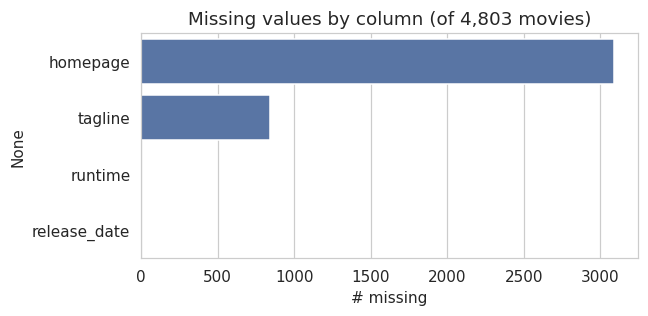

In [5]:
miss = df[["overview", "release_date", "runtime", "tagline", "homepage"]].isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=miss.values, y=miss.index, color="#4C72B0")
plt.title("Missing values by column (of 4,803 movies)")
plt.xlabel("# missing")
plt.tight_layout()
plt.show()


`tagline` is missing 17% of the time and `homepage` 64% of the time — neither is used below. `overview` is only missing 3 times, which is why it's a safe backbone for a content-based model.

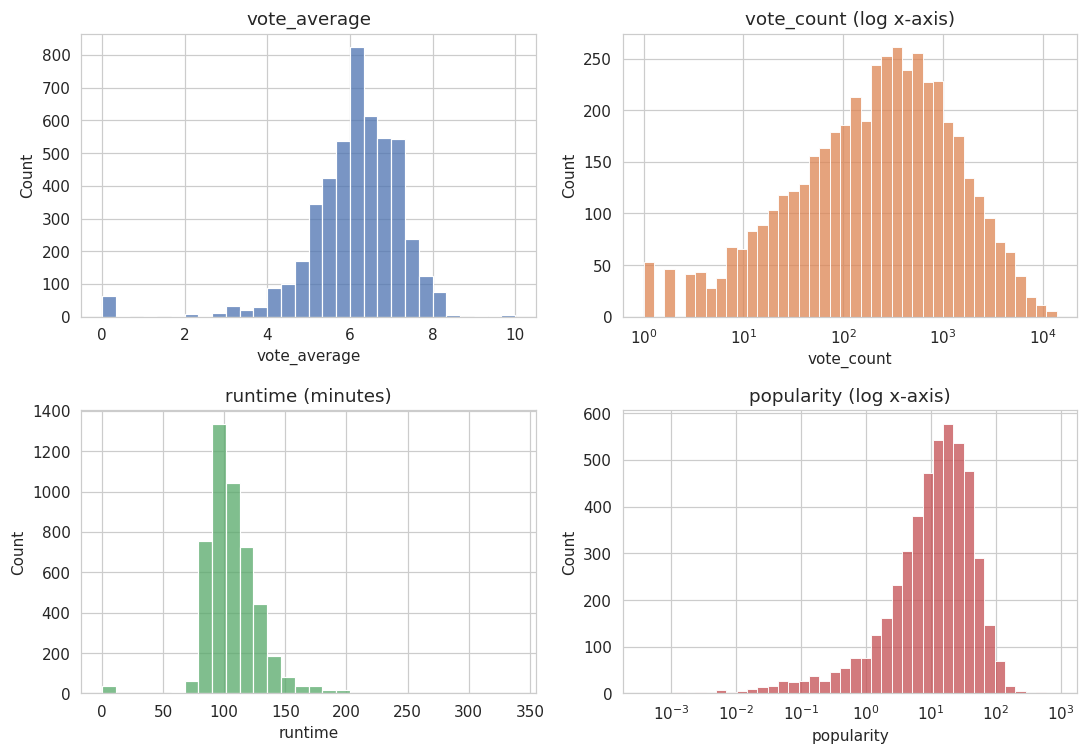

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
sns.histplot(df["vote_average"], bins=30, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("vote_average")
sns.histplot(df[df["vote_count"] > 0]["vote_count"], bins=40, ax=axes[0, 1], color="#DD8452", log_scale=(True, False))
axes[0, 1].set_title("vote_count (log x-axis)")
sns.histplot(df["runtime"].dropna(), bins=30, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("runtime (minutes)")
sns.histplot(df[df["popularity"] > 0]["popularity"], bins=40, ax=axes[1, 1], color="#C44E52", log_scale=(True, False))
axes[1, 1].set_title("popularity (log x-axis)")
plt.tight_layout()
plt.show()


`vote_average` is roughly bell-shaped around 6 (plus a spike of zeros — movies with no votes at all). `vote_count` and `popularity` are both heavily right-skewed: a handful of blockbusters dominate, which is exactly why the weighted-rating formula matters — a raw average would let a movie with 3 votes of 10/10 outrank *The Godfather*.

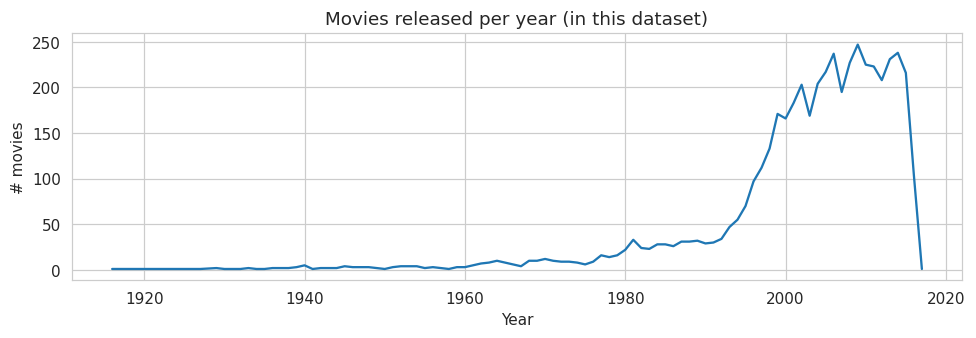

In [7]:
by_year = df.dropna(subset=["release_year"]).groupby("release_year").size()
plt.figure(figsize=(9, 3.2))
by_year.plot()
plt.title("Movies released per year (in this dataset)")
plt.xlabel("Year"); plt.ylabel("# movies")
plt.tight_layout()
plt.show()


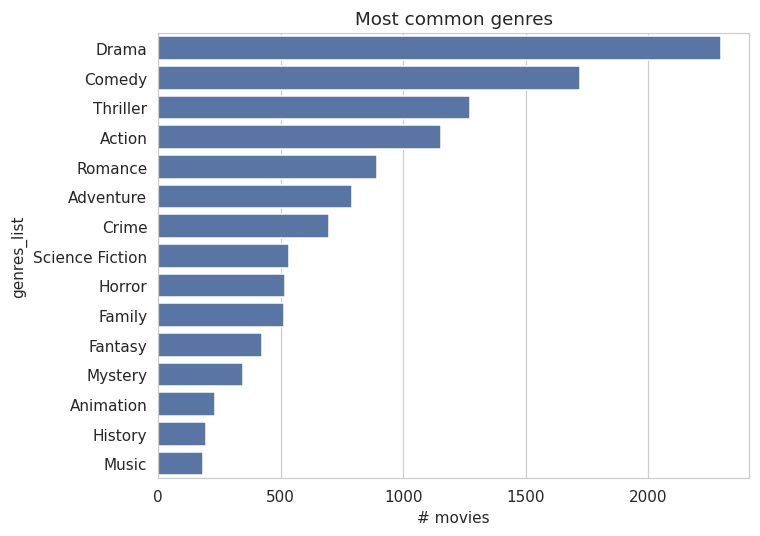

In [8]:
genre_counts = df["genres_list"].explode().value_counts().head(15)
plt.figure(figsize=(7, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#4C72B0")
plt.title("Most common genres")
plt.xlabel("# movies")
plt.tight_layout()
plt.show()


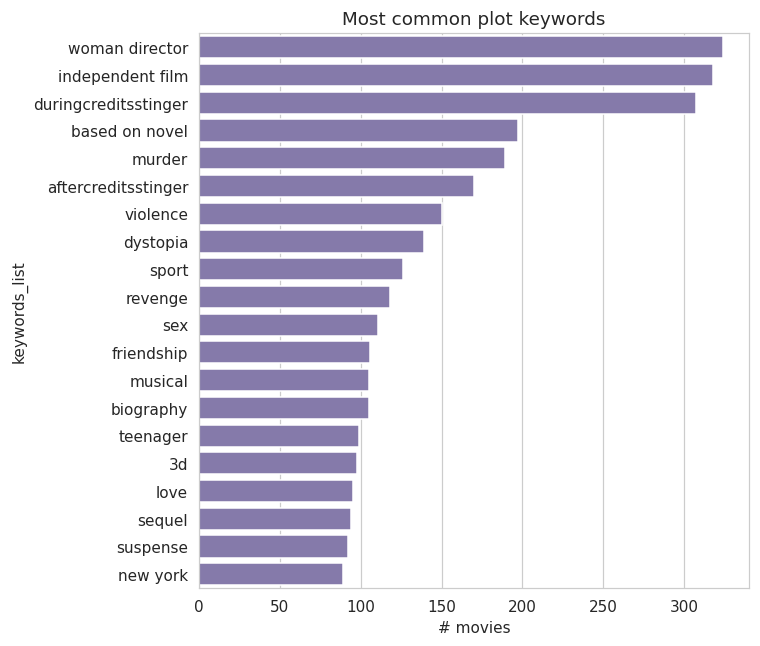

In [9]:
kw_counts = df["keywords_list"].explode().value_counts().head(20)
plt.figure(figsize=(7, 6))
sns.barplot(x=kw_counts.values, y=kw_counts.index, color="#8172B2")
plt.title("Most common plot keywords")
plt.xlabel("# movies")
plt.tight_layout()
plt.show()


Drama and Comedy dominate by a wide margin, and the keyword list is mostly generic plot descriptors (`woman director`, `based on novel`, `independent film`) rather than genre-specific words — which is exactly why keywords work best *combined* with genres and cast rather than alone.

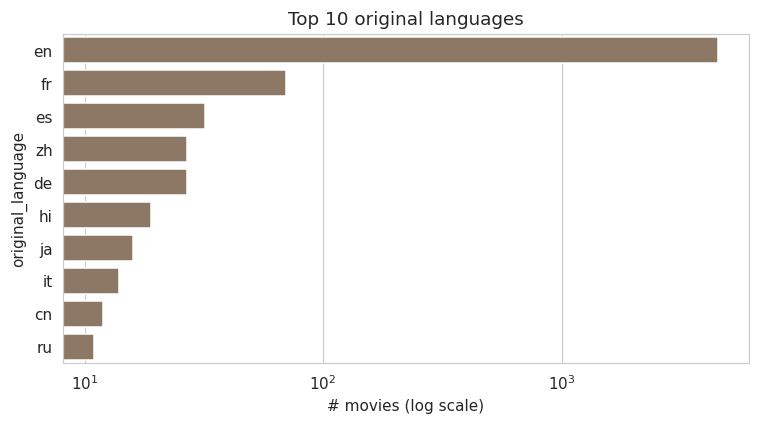

In [10]:
lang_counts = df["original_language"].value_counts().head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x=lang_counts.values, y=lang_counts.index, color="#937860")
plt.title("Top 10 original languages")
plt.xlabel("# movies (log scale)")
plt.xscale("log")
plt.tight_layout()
plt.show()


**Caveat worth flagging**: 94% of this catalog is English-language. Any recommender built on it will have a thin, sometimes odd neighborhood for non-English movies simply because there isn't much else in the same language to compare against.

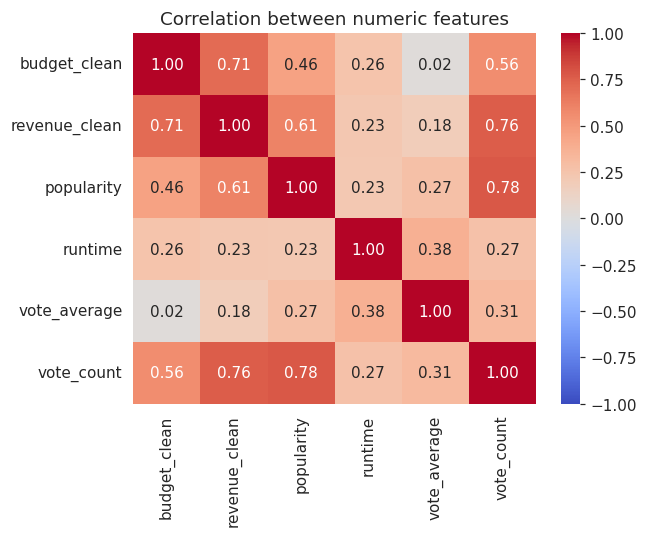

In [11]:
num_cols = ["budget_clean", "revenue_clean", "popularity", "runtime", "vote_average", "vote_count"]
corr = df[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()


Budget correlates fairly strongly with revenue (0.71) and only barely with rating (0.02) — bigger budgets do not buy a better score, just a better chance of a bigger gross. `vote_count` tracks `popularity` closely (0.78), which is why the two make a sensible pair to blend for a demographic/popularity hybrid score (Section 6).

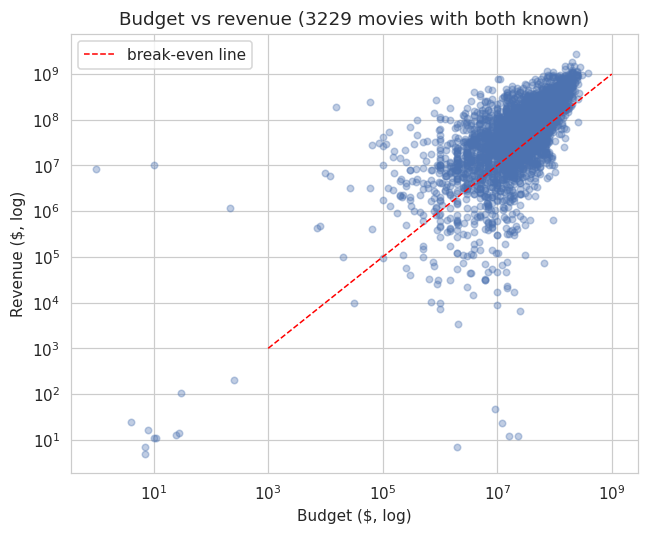

In [12]:
valid = df.dropna(subset=["budget_clean", "revenue_clean"])
plt.figure(figsize=(6, 5))
plt.scatter(valid["budget_clean"], valid["revenue_clean"], alpha=0.35, s=18, color="#4C72B0")
plt.plot([1e3, 1e9], [1e3, 1e9], "r--", lw=1, label="break-even line")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Budget ($, log)"); plt.ylabel("Revenue ($, log)")
plt.title(f"Budget vs revenue ({len(valid)} movies with both known)")
plt.legend()
plt.tight_layout()
plt.show()


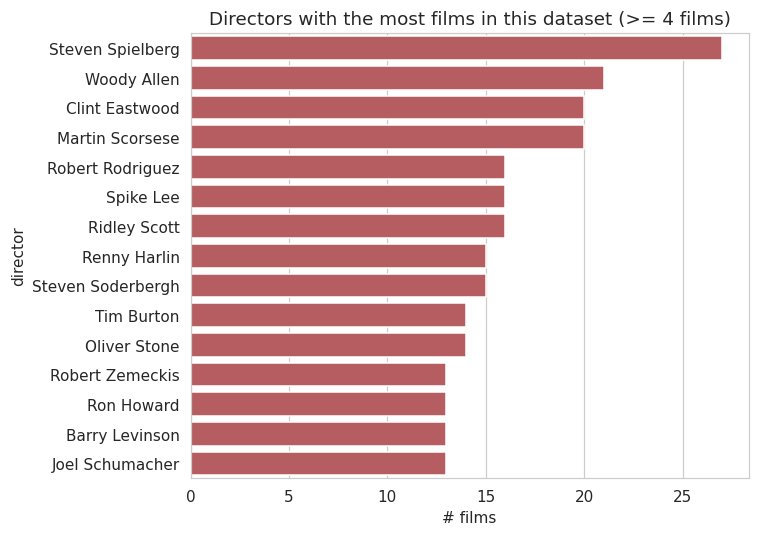

In [13]:
dir_stats = (df.dropna(subset=["director"])
               .groupby("director")
               .agg(n_movies=("id", "count"), avg_rating=("vote_average", "mean"))
               .query("n_movies >= 4")
               .sort_values("n_movies", ascending=False)
               .head(15))
plt.figure(figsize=(7, 5))
sns.barplot(x="n_movies", y=dir_stats.index, data=dir_stats, color="#C44E52")
plt.title("Directors with the most films in this dataset (>= 4 films)")
plt.xlabel("# films")
plt.tight_layout()
plt.show()


Steven Spielberg (27 films), Woody Allen (21), Clint Eastwood and Martin Scorsese (20 each) anchor the catalog. This is the whole motivation for Section 8: if someone picks a Scorsese movie, a model that only reads the *plot summary* has no way to know that — but a model that reads `crew` does.

## 5. Demographic filtering: "Top Rated" leaderboard

This is the same idea as the original notebook: only rank movies that cleared the 90th
percentile of `vote_count` (`m`, computed above), so a movie with 5 votes of 10/10 can't beat
*The Shawshank Redemption*. `weighted_rating` was already computed for every row in Section 3;
here it's just sorted and restricted to the qualifying subset.

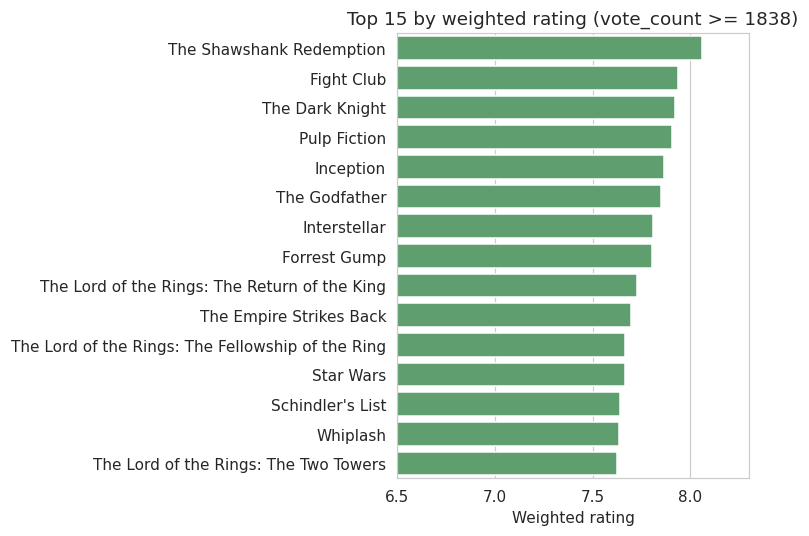

In [14]:
top_rated = df[df["vote_count"] >= m].sort_values("weighted_rating", ascending=False)
top15 = top_rated.head(15)
plt.figure(figsize=(7, 5))
sns.barplot(x="weighted_rating", y="display_title", data=top15, color="#55A868")
plt.title(f"Top 15 by weighted rating (vote_count >= {m:.0f})")
plt.xlabel("Weighted rating"); plt.ylabel("")
plt.xlim(6.5, 8.3)
plt.tight_layout()
plt.show()


## 6. Popularity-based ranking + a demographic/popularity hybrid score

Min-max scale `weighted_rating` and `popularity`, then blend them 50/50. This has nothing to do with the *content*-based recommender built later — it's a separate, non-personalized "what's hot and good right now" view, useful for a cold-start user with no selected movie yet.

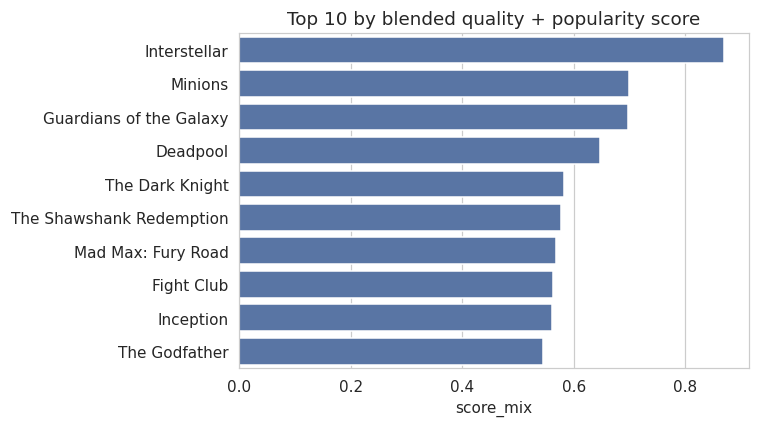

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaled = MinMaxScaler().fit_transform(top_rated[["weighted_rating", "popularity"]])
top_rated = top_rated.copy()
top_rated["weighted_rating_scaled"] = scaled[:, 0]
top_rated["popularity_scaled"] = scaled[:, 1]
top_rated["score_mix"] = 0.5 * top_rated["weighted_rating_scaled"] + 0.5 * top_rated["popularity_scaled"]

rank_df = top_rated.sort_values("score_mix", ascending=False).head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x="score_mix", y="display_title", data=rank_df, color="#4C72B0")
plt.title("Top 10 by blended quality + popularity score")
plt.xlabel("score_mix"); plt.ylabel("")
plt.tight_layout()
plt.show()


## 7. Content-based models: building the text features

Two ingredients get vectorized separately below, then combined:

- **`overview`** — free-text plot summary. Good at catching *thematically* similar movies,
  weak at catching *stylistically* similar ones.
- **`soup`** — genres + keywords + top-3 billed cast + director, all squashed into single
  tokens (`"Sam Worthington"` → `samworthington`) so a vectorizer can't confuse two different
  people who happen to share a first name. The director's name is repeated 3x to weight it
  more heavily than a single keyword — directorial style tends to be a stronger "if you liked
  this, you'll like that" signal than any one keyword.

In [16]:
def clean_token(s):
    return str(s).replace(" ", "").lower()

def make_soup(row, director_weight=3):
    parts = [clean_token(g) for g in row["genres_list"]]
    parts += [clean_token(k) for k in row["keywords_list"]]
    parts += [clean_token(c) for c in row["cast_top3"]]
    if isinstance(row["director"], str):
        parts += [clean_token(row["director"])] * director_weight
    return " ".join(parts)

df["soup"] = df.apply(make_soup, axis=1)
df["combined_text"] = df["overview"] + " " + df["soup"]
df[["display_title", "soup"]].head(3)


,display_title,soup
0,Avatar,action adventure fantasy sciencefiction cultur...
1,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...
2,Spectre,action adventure crime spy basedonnovel secret...


## 8. Fixing the coverage problem

`vote_count >= 10`, which just filters out the essentially
unrated entries (no votes, no meaningful signal) while keeping 91% of the catalog.

In [17]:
eligible = df[df["vote_count"] >= 10].reset_index(drop=True)
print(f"eligible for content-based recs: {len(eligible)} / {len(df)} movies "
      f"({len(eligible) / len(df):.1%}) -- vs. {(df['vote_count'] >= m).sum()} under the original filter")
assert eligible["display_title"].is_unique
title_to_pos = pd.Series(eligible.index, index=eligible["display_title"])


eligible for content-based recs: 4392 / 4803 movies (91.4%) -- vs. 481 under the original filter


## 9. Model A — plot similarity (`overview` only)

TF-IDF on the overview text, then a similarity score
between every pair of movies. The original used `sigmoid_kernel`; **cosine similarity** is the
more standard (and more interpretable — it's bounded in [0, 1] and literally the cosine of the
angle between two TF-IDF vectors) choice for text similarity, so it's used everywhere below.
The cell after this one checks whether that choice actually changes anything.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, sigmoid_kernel
from sklearn.decomposition import TruncatedSVD

tfv_overview = TfidfVectorizer(stop_words="english", min_df=2)
mat_overview = tfv_overview.fit_transform(eligible["overview"])
print("overview TF-IDF matrix:", mat_overview.shape)


overview TF-IDF matrix: (4392, 10086)


In [19]:
# sanity check: does cosine similarity actually rank differently than sigmoid_kernel here?
idx = title_to_pos["Avatar"]
cos_top = np.argsort(-cosine_similarity(mat_overview[idx], mat_overview).ravel())
sig_top = np.argsort(-sigmoid_kernel(mat_overview[idx], mat_overview).ravel())
print("cosine   top 6:", eligible.loc[cos_top[:6], "display_title"].tolist())
print("sigmoid  top 6:", eligible.loc[sig_top[:6], "display_title"].tolist())


cosine   top 6: ['Avatar', 'Apollo 18', 'The American', 'Obitaemyy Ostrov', 'The Matrix', 'Tears of the Sun']
sigmoid  top 6: ['Avatar', 'Apollo 18', 'The American', 'Obitaemyy Ostrov', 'The Matrix', 'Tears of the Sun']


They agree almost exactly — for L2-normalized TF-IDF vectors, `sigmoid_kernel`'s ranking usually tracks cosine similarity closely, so the original model's choice wasn't *wrong*. Cosine similarity is kept from here on mainly because its scores are directly interpretable (0 = unrelated, 1 = identical) and it's the standard choice in every recommender-systems reference, not because the results differ much.

## 10. Model B — metadata similarity (genres, keywords, cast, director)


 `CountVectorizer` (not TF-IDF) is the
right tool here: the `soup` tokens are already curated, meaningful units (a genre, an actor's
full name, a director's full name) rather than free prose, so there's no need to down-weight
frequently-occurring ones the way TF-IDF's IDF term would — a shared *director* is a strong
signal precisely because it's specific, even if that director shows up in the soup of 27
different movies.

In [20]:
cv_soup = CountVectorizer(stop_words="english", min_df=2)
mat_soup = cv_soup.fit_transform(eligible["soup"])
print("soup CountVectorizer matrix:", mat_soup.shape)


soup CountVectorizer matrix: (4392, 7185)


## 11. Model C — combined (overview + metadata)

Concatenate the plot text and the soup into one document per movie and TF-IDF the result, so a single similarity score reflects both *what happens* in the movie and *who made it*.

In [21]:
tfv_combined = TfidfVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))
mat_combined = tfv_combined.fit_transform(eligible["combined_text"])
print("combined TF-IDF matrix:", mat_combined.shape)


combined TF-IDF matrix: (4392, 26229)


## 12. Model D — latent semantic analysis (SVD on the combined matrix)

A genuinely different technique rather than a variation on TF-IDF: `TruncatedSVD` compresses the ~26k-dimensional sparse combined matrix down to 150 dense latent dimensions. Two movies can end up similar in this space even without sharing a single exact word or name, because the SVD groups co-occurring terms — this is the same idea search engines used before neural embeddings existed.

In [22]:
svd = TruncatedSVD(n_components=150, random_state=42)
mat_svd = svd.fit_transform(mat_combined)
print("SVD-reduced matrix:", mat_svd.shape, "| cumulative explained variance:", round(svd.explained_variance_ratio_.sum(), 3))


SVD-reduced matrix: (4392, 150) | cumulative explained variance: 0.128


## 13. A single `recommend()` function for every model

One more change from the original: instead of precomputing and storing a full N x N similarity
matrix (`sig`, saved as a 481x481 array before — harmless at that size, but it grows
*quadratically*, so the same approach at, say, 40,000 movies would mean a 12.8 GB matrix sitting
in memory), similarity is computed **on demand**: one movie's vector against every other movie's
vector, which is a single fast sparse matrix-vector operation. This also means adding a new
movie later doesn't require rebuilding an N x N matrix — its vector alone needs to be computed
against the existing ones.

In [23]:
def recommend(title, matrix, top_n=10, dense=False):
    idx = title_to_pos[title]
    row = matrix[idx].reshape(1, -1) if dense else matrix[idx]
    sims = cosine_similarity(row, matrix).ravel()
    order = np.argsort(-sims)
    order = order[order != idx][:top_n]
    return eligible.loc[order, ["display_title", "vote_average", "director"]].assign(similarity=sims[order].round(3))

import time
t0 = time.time()
_ = recommend("Avatar", mat_combined)
print(f"single recommendation computed in {(time.time() - t0) * 1000:.1f} ms -- fast enough for an interactive app")


single recommendation computed in 4.5 ms -- fast enough for an interactive app


## 14. Case study: what does each model actually recommend for the same movie?

*Avatar* is a good test case because it's a James Cameron sci-fi epic — a model that only reads
the plot summary has no way to know Cameron directed it, while a model that reads `crew` does.

In [24]:
comparison = pd.DataFrame({
    "A. Overview only": recommend("Avatar", mat_overview)["display_title"].values,
    "B. Metadata soup": recommend("Avatar", mat_soup)["display_title"].values,
    "C. Combined": recommend("Avatar", mat_combined)["display_title"].values,
    "D. SVD/LSA": recommend("Avatar", mat_svd, dense=True)["display_title"].values,
})
comparison.index = range(1, 11)
comparison


,A. Overview only,B. Metadata soup,C. Combined,D. SVD/LSA
1,Apollo 18,Aliens,Aliens,Aliens
2,The American,The Abyss,True Lies,The Abyss
3,Obitaemyy Ostrov,Terminator 2: Judgment Day,Terminator 2: Judgment Day,The Terminator
4,The Matrix,The Terminator,The Terminator,Galaxina
5,Tears of the Sun,True Lies,The Abyss,Terminator 2: Judgment Day
6,The Adventures of Pluto Nash,Titanic,Titanic,Silent Running
7,Semi-Pro,Star Trek Into Darkness,Obitaemyy Ostrov,Ender's Game
8,Hanna,Stargate: The Ark of Truth,Apollo 18,Obitaemyy Ostrov
9,Beowulf,Megaforce,Star Trek Into Darkness,True Lies
10,Supernova,Six-String Samurai,Battle: Los Angeles,Serenity


**Model A (overview only)** surfaces movies with similar-sounding plot summaries — some reasonable sci-fi, but also *Semi-Pro*, a basketball comedy that has nothing in common with *Avatar* beyond a few overlapping words. **Models B, C, and D** all surface *Aliens*, *The Terminator*, *Terminator 2*, *True Lies*, and *The Abyss* — which is to say, James Cameron's other films — because they can actually see the `director` field. That's the coverage the original model was missing entirely.

## 15. Model E — hybrid re-ranking (similarity + quality boost)

Pure similarity doesn't know or care whether a "similar" movie is any good. This re-ranks the
top 30 most-similar candidates by blending normalized similarity with normalized
`weighted_rating` (65% similarity / 35% quality by default), so a mediocre-but-similar movie
can be outranked by a genuinely great one that's still a reasonable match.

In [25]:
def recommend_hybrid(title, matrix, top_n=10, pool=30, quality_weight=0.35, dense=False):
    idx = title_to_pos[title]
    row = matrix[idx].reshape(1, -1) if dense else matrix[idx]
    sims = cosine_similarity(row, matrix).ravel()
    order = np.argsort(-sims)
    order = order[order != idx][:pool]

    cand = eligible.loc[order, ["display_title", "vote_average", "weighted_rating"]].copy()
    cand["sim"] = sims[order]
    cand["sim_norm"] = (cand["sim"] - cand["sim"].min()) / ((cand["sim"].max() - cand["sim"].min()) or 1.0)
    cand["quality_norm"] = (cand["weighted_rating"] - cand["weighted_rating"].min()) / \
                            ((cand["weighted_rating"].max() - cand["weighted_rating"].min()) or 1.0)
    cand["blend"] = (1 - quality_weight) * cand["sim_norm"] + quality_weight * cand["quality_norm"]
    return cand.sort_values("blend", ascending=False).head(top_n)[["display_title", "vote_average", "sim", "blend"]]

recommend_hybrid("Avatar", mat_combined)


,display_title,vote_average,sim,blend
2383,Aliens,7.7,0.300972,0.944475
279,Terminator 2: Judgment Day,7.7,0.240079,0.800888
3358,The Terminator,7.3,0.226683,0.704170
282,True Lies,6.8,0.264122,0.682324
25,Titanic,7.5,0.186097,0.659022
585,The Abyss,7.1,0.226068,0.588675
3101,Alien,7.9,0.066622,0.369708
47,Star Trek Into Darkness,7.4,0.090412,0.356613
74,Edge of Tomorrow,7.6,0.061234,0.314869
1348,Gattaca,7.5,0.061039,0.228990


## 16. Which model is actually best? A quantitative comparison

One example (*Avatar*) is a nice illustration but it's still just one anecdote. With no user
ratings on *recommendations* to learn from, there's no ground truth to score against directly —
but two reasonable, checkable proxies are:

- **Genre overlap rate** — of the top-10 recommended movies, what fraction share at least one
  genre with the movie you searched for?
- **Director match rate** — what fraction were made by the *same director*? (Overview-only text
  similarity has no mechanism to find this at all, so this number should expose exactly that
  gap.)
- **Average rating of what's recommended** — does the model tend to surface decent movies, or
  does it not care?

These are computed across a random sample of 60 movies (each with at least 50 votes, so the
comparison itself isn't dominated by obscure titles) and averaged.

In [26]:
rng_sample = eligible.loc[eligible["vote_count"] >= 50, "id"].sample(60, random_state=42)
sample_titles = eligible.set_index("id").loc[rng_sample, "display_title"].tolist()

def eval_model(matrix, dense=False, hybrid=False):
    genre_overlap, director_match, avg_rating = [], [], []
    for title in sample_titles:
        idx = title_to_pos[title]
        q_genres = set(eligible.loc[idx, "genres_list"])
        q_dir = eligible.loc[idx, "director"]

        if hybrid:
            rec_idx = recommend_hybrid(title, matrix, top_n=10, dense=dense).index
        else:
            rec_idx = recommend(title, matrix, top_n=10, dense=dense).index

        rec_rows = eligible.loc[rec_idx]
        genre_overlap.append(rec_rows["genres_list"].apply(lambda gl: len(set(gl) & q_genres) > 0).mean())
        if isinstance(q_dir, str):
            director_match.append((rec_rows["director"] == q_dir).mean())
        avg_rating.append(rec_rows["vote_average"].mean())

    return {
        "genre_overlap_rate": np.mean(genre_overlap),
        "director_match_rate": np.mean(director_match),
        "avg_recommended_rating": np.mean(avg_rating),
    }

results = {
    "A. Overview only": eval_model(mat_overview),
    "B. Metadata soup": eval_model(mat_soup),
    "C. Combined": eval_model(mat_combined),
    "D. SVD/LSA (150d)": eval_model(mat_svd, dense=True),
    "E. Combined + quality-boost hybrid": eval_model(mat_combined, hybrid=True),
}
comparison_table = pd.DataFrame(results).T.round(3)
comparison_table


,genre_overlap_rate,director_match_rate,avg_recommended_rating
A. Overview only,0.663,0.012,6.201
B. Metadata soup,0.912,0.373,6.111
C. Combined,0.785,0.367,6.269
D. SVD/LSA (150d),0.858,0.338,6.265
E. Combined + quality-boost hybrid,0.808,0.363,6.625


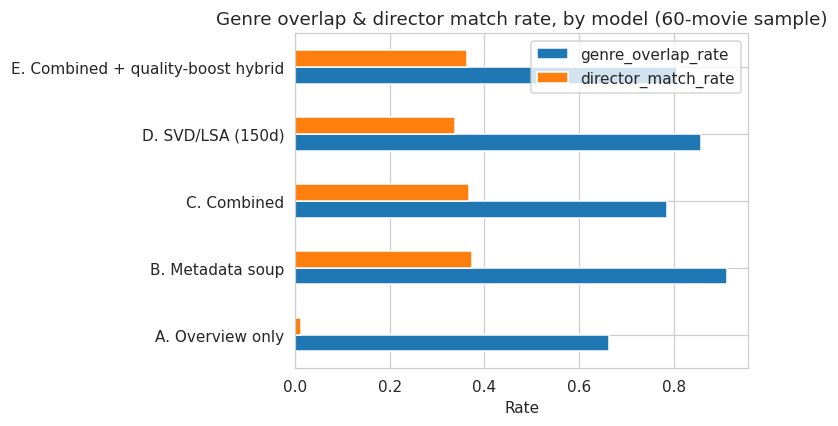

In [27]:
comparison_table[["genre_overlap_rate", "director_match_rate"]].plot.barh(figsize=(7, 4))
plt.title("Genre overlap & director match rate, by model (60-movie sample)")
plt.xlabel("Rate")
plt.tight_layout()
plt.show()


**Reading the numbers:**

- Overview-only's director-match rate is near zero — it has no way to see who directed
  anything, confirmed. Every metadata-aware model jumps to roughly 35–37%.
- Metadata soup alone gets the *highest* genre overlap (91%), because genres are one of its
  direct inputs. Combining it with the overview text (Model C) trades a little of that genre
  purity for a small lift in average recommended rating and a model that also picks up on
  thematic/plot similarity, not just categorical tags.
- The SVD model lands in between B and C on genre overlap, at a fraction of the dimensionality
  — useful mainly as a scalability lever for a much larger catalog, less so as a quality win
  here.
- The hybrid re-ranker (E) gets the **highest average rating of anything recommended** (6.63 vs.
  6.1–6.3 elsewhere) for a small, deliberate trade in raw genre-overlap — exactly the trade it
  was built to make.

**Bottom line:** for a "more like this" feature, Model C (combined) or Model E (hybrid) is the
better default; Model B (pure metadata) is worth keeping as an explicit option for someone who
explicitly wants "more from this director/cast," and Model A (overview-only) is worth keeping
only as a baseline / for the rare case where genre and cast metadata is missing.

## 17. What this dataset can't do: collaborative filtering

Every model above is **content-based** — it only ever looks at a movie's own attributes.
Classic **collaborative filtering** (matrix factorization or user/item k-NN on a user x movie
ratings matrix) needs actual user ratings data, e.g. MovieLens' `ratings.csv`, which isn't part
of this TMDB 5000 dataset (it only has aggregate `vote_average`/`vote_count`, not individual
ratings). If per-user ratings become available later, that's the natural next model to add,
and it would answer a different question than anything above: not *what's similar to this
movie*, but *what do people like you tend to enjoy*.

## 18. Exporting artifacts for the Streamlit app

- **Relative paths**, into a `model_artifacts/` folder sitting next to the notebook — works on
  any machine, including whoever's grading or reviewing this project.
- **Vectorizer + sparse matrix, not a precomputed similarity matrix** — per Section 13, this
  is smaller on disk and scales to a much bigger catalog without a rebuild.

In [28]:
import joblib, os

ART_DIR = "model_artifacts"
os.makedirs(ART_DIR, exist_ok=True)

app_columns = ["id", "display_title", "original_title", "overview", "genres_list",
               "director", "cast_top3", "release_year", "vote_average", "vote_count",
               "weighted_rating"]
eligible[app_columns].to_csv(f"{ART_DIR}/movies_for_app.csv", index=False)
top_rated[["display_title", "vote_average", "vote_count", "weighted_rating", "popularity"]] \
    .head(50).to_csv(f"{ART_DIR}/top_rated_for_app.csv", index=False)

joblib.dump(tfv_overview, f"{ART_DIR}/tfidf_overview_vectorizer.pkl")
joblib.dump(mat_overview, f"{ART_DIR}/tfidf_overview_matrix.pkl")
joblib.dump(cv_soup, f"{ART_DIR}/count_soup_vectorizer.pkl")
joblib.dump(mat_soup, f"{ART_DIR}/count_soup_matrix.pkl")
joblib.dump(tfv_combined, f"{ART_DIR}/tfidf_combined_vectorizer.pkl")
joblib.dump(mat_combined, f"{ART_DIR}/tfidf_combined_matrix.pkl")

print("Artifacts written to", os.path.abspath(ART_DIR))
for f in sorted(os.listdir(ART_DIR)):
    size_kb = os.path.getsize(os.path.join(ART_DIR, f)) / 1024
    print(f"  {f:<32s} {size_kb:>9.1f} KB")


Artifacts written to /home/claude/final/model_artifacts
  count_soup_matrix.pkl                667.9 KB
  count_soup_vectorizer.pkl            115.2 KB
  movies_for_app.csv                  2036.7 KB
  tfidf_combined_matrix.pkl           2304.3 KB
  tfidf_combined_vectorizer.pkl        645.1 KB
  tfidf_overview_matrix.pkl           1238.1 KB
  tfidf_overview_vectorizer.pkl        205.9 KB
  top_rated_for_app.csv                  2.7 KB


## 19. Summary

| # | Model | What it captures | Where it's strong |
|---|-------|-------------------|--------------------|
| A | Overview TF-IDF + cosine | Plot/theme text | Baseline; works even with no cast/genre data |
| B | Metadata soup + cosine | Genre, keywords, cast, director | "More from this director/cast" |
| C | Combined + cosine | Both of the above | Best general-purpose default |
| D | SVD/LSA on combined | Latent topics, dense & compact | Scaling to a much larger catalog |
| E | Combined + quality-boost hybrid | Similarity re-ranked by weighted rating | Avoids recommending a similar-but-weak movie |

Plus two non-personalized views carried over from the original notebook: the weighted-rating
**Top Rated** leaderboard and the popularity/quality **hybrid score** — both useful for a
cold-start user who hasn't picked a movie yet.
